In [31]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mocap_utils import MocapProcessor


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# import data from csv stored in cal folder

mocap_df = pd.read_csv("/home/austin/crazyflie-firmware/examples/app_flapper_swarm/analysis/cal/mocap1cal01.csv")
flapper_df = pd.read_csv("/home/austin/crazyflie-firmware/examples/app_flapper_swarm/analysis/cal/flap1cal01.csv")

In [33]:
# print the column names of the dataframes
print("mocap columns: ", mocap_df.columns)
print("flapper columns: ", flapper_df.columns)

mocap columns:  Index(['Frame', 'Time (Seconds)', 'qX', 'qY', 'qZ', 'qW', 'pX', 'pY', 'pZ'], dtype='str')
flapper columns:  Index(['timestamp', 'stateEstimateZ.vx', 'stateEstimateZ.vy',
       'stateEstimateZ.vz', 'stateEstimateZ.rateYaw', 't_s'],
      dtype='str')


In [34]:
# do linear interpolation on each data sets to fill in any nan values
mocap_df.interpolate(method='linear', inplace=True)
flapper_df.interpolate(method='linear', inplace=True)

,timestamp,stateEstimateZ.vx,stateEstimateZ.vy,stateEstimateZ.vz,stateEstimateZ.rateYaw,t_s
0,30107.906,0,1,-1,-1,0.000000
1,30117.998,0,0,-1,-3,0.010092
2,30127.637,0,1,-1,0,0.019731
3,30137.746,0,0,-1,-4,0.029840
4,30147.401,-1,1,-1,0,0.039495
...,...,...,...,...,...,...
5048,79958.387,403,134,-3,2,49.850481
5049,79968.486,403,134,-3,5,49.860580
5050,79978.124,404,134,-3,10,49.870218
5051,79988.226,405,133,-3,-1,49.880320


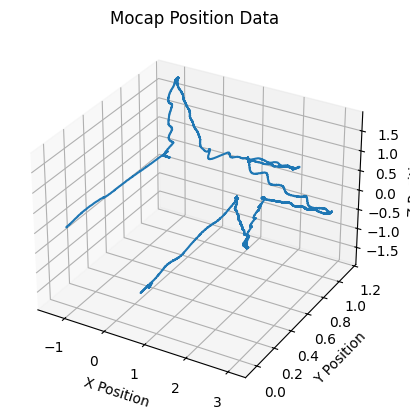

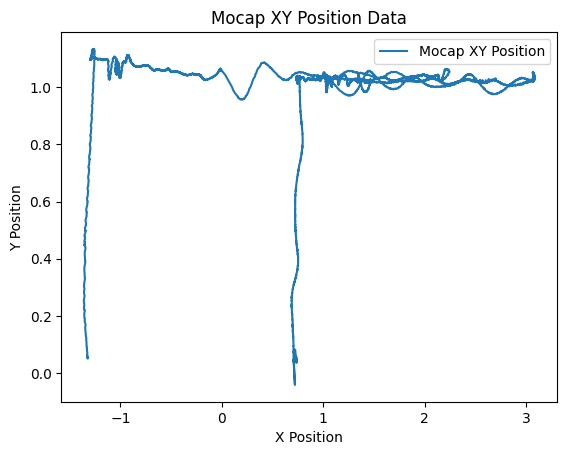

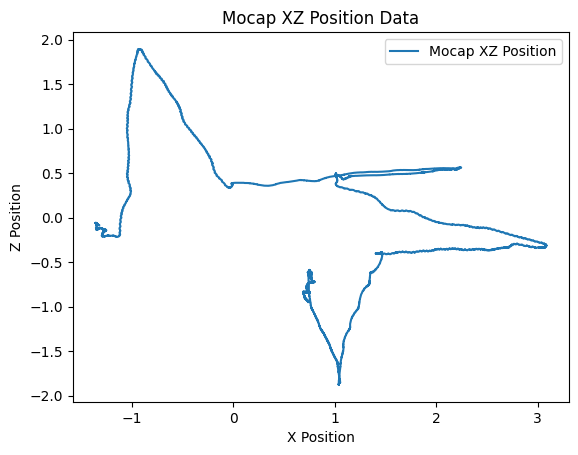

In [35]:
# plot mocap position data 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(mocap_df['pX'], mocap_df['pY'], mocap_df['pZ'], label='Mocap Position')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('Mocap Position Data')
plt.show()

# plot xy position data
plt.figure()
plt.plot(mocap_df['pX'], mocap_df['pY'], label='Mocap XY Position')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Mocap XY Position Data')
plt.legend()
plt.show()

# plot XZ position data
plt.figure()
plt.plot(mocap_df['pX'], mocap_df['pZ'], label='Mocap XZ Position')
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.title('Mocap XZ Position Data')
plt.legend()
plt.show()


In [36]:
from scipy.spatial.transform import Rotation as R

# Change-of-basis matrix: mocap (X-left, Y-up, Z-fwd) → FLU (X-fwd, Y-left, Z-up)
# Each row says: "new axis i = which old axis?"
T = np.array([[0, 0, 1],   # X_new(fwd)  = Z_old
              [1, 0, 0],   # Y_new(left) = X_old
              [0, 1, 0]])  # Z_new(up)   = Y_old
# det(T) = +1  →  proper rotation (no reflections)

# --- Position transform ---
pos_old = mocap_df[['pX', 'pY', 'pZ']].values
pos_new = (T @ pos_old.T).T
mocap_df['X'] = pos_new[:, 0]
mocap_df['Y'] = pos_new[:, 1]
mocap_df['Z'] = pos_new[:, 2]

# --- Orientation transform via rotation matrices (fully transparent, no sign hacks) ---
quats_mocap = mocap_df[['qX', 'qY', 'qZ', 'qW']].values  # scipy [x,y,z,w] order
rot_old = R.from_quat(quats_mocap)
R_old = rot_old.as_matrix()                        # (N, 3, 3)
R_new = np.einsum('ia,nab,jb->nij', T, R_old, T)  # R_new = T @ R_old @ T^T
rot_new = R.from_matrix(R_new)

# Euler angles — intrinsic ZYX (yaw-pitch-roll), NO negations
# FLU right-hand rule:
#   pitch about Y(left): +θ → Ry rotates X toward -Z → nose DOWN → forward
#   yaw   about Z(up):   +ψ → nose toward +Y → CCW from above
#   roll  about X(fwd):  +φ → right wing down
euler = rot_new.as_euler('ZYX', degrees=True)

mocap_df['yaw']   = euler[:, 0]
mocap_df['pitch'] = euler[:, 1]
mocap_df['roll']  = euler[:, 2]

print("Transformed (no sign hacks):")
print(mocap_df[['X', 'Y', 'Z', 'roll', 'pitch', 'yaw']].head(10))

Transformed (no sign hacks):
          X         Y         Z      roll     pitch        yaw
0 -0.084264 -1.322286  0.051800  0.079944  0.704526 -17.389079
1 -0.084187 -1.322045  0.051406  0.257361  0.617091 -17.340615
2 -0.084221 -1.322320  0.051860  0.131529  0.747919 -17.403253
3 -0.084124 -1.322168  0.051817  0.194025  0.648645 -17.273808
4 -0.084118 -1.322164  0.051805  0.239570  0.687615 -17.294039
5 -0.084232 -1.322101  0.051626  0.235790  0.623362 -17.359729
6 -0.084108 -1.322166  0.051879  0.236348  0.687901 -17.282226
7 -0.084266 -1.322119  0.051549  0.225489  0.671277 -17.396483
8 -0.084252 -1.322038  0.051650  0.261110  0.655271 -17.393296
9 -0.084220 -1.322283  0.052212  0.125516  0.800396 -17.328298


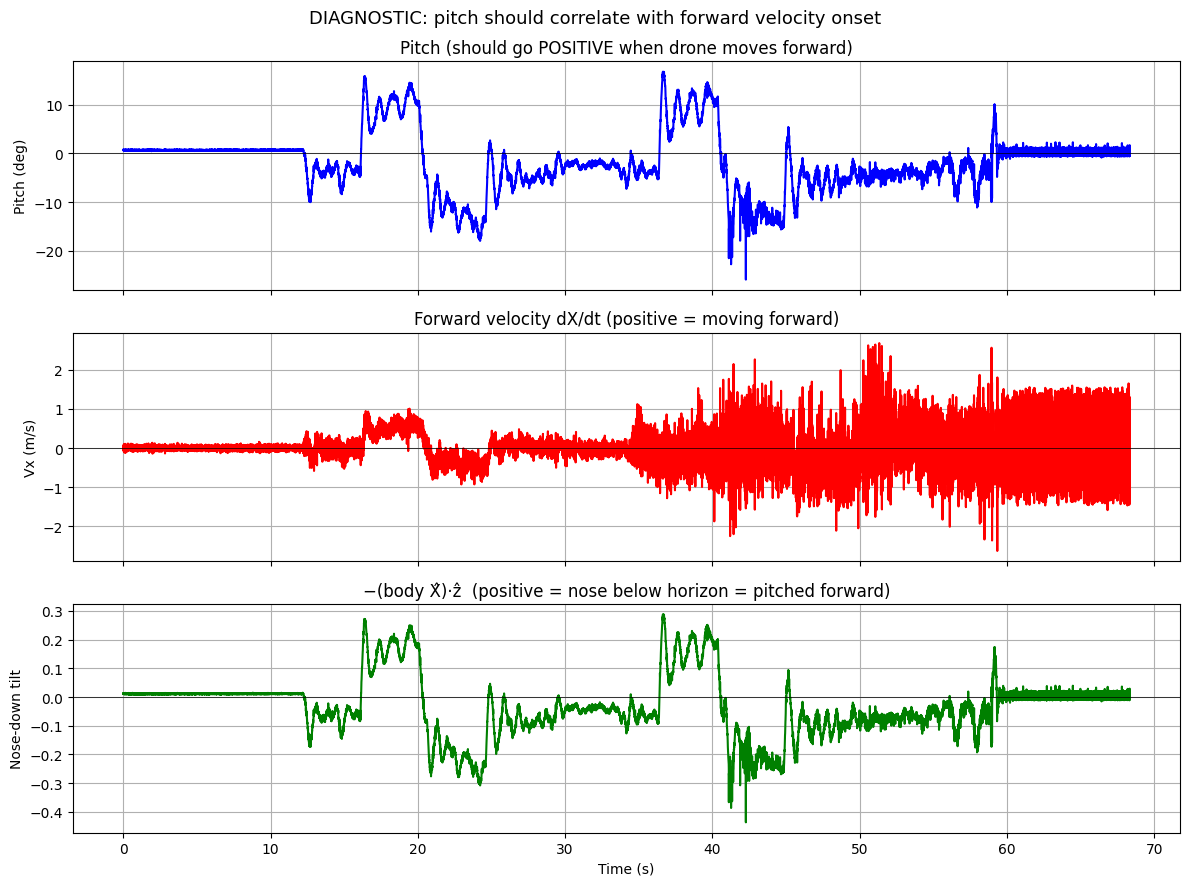

Peak forward velocity at t=19.4s:  Vx=1.01 m/s
Pitch at that time: 13.69°
→ If pitch is NEGATIVE here, the mocap quaternion convention is inverted.


In [37]:
# === DIAGNOSTIC: verify pitch convention against known flight ===
# When the drone accelerates forward, it MUST pitch nose-down.
# In correct FLU, that is positive pitch.
# Plot pitch alongside forward velocity so we can check correlation.

t = mocap_df['Time (Seconds)'].values
dt = np.diff(t)
vx = np.diff(mocap_df['X'].values) / dt   # forward velocity
t_mid = 0.5 * (t[:-1] + t[1:])

# Also compute body-X direction in world frame (the drone's nose direction)
body_fwd = rot_new.apply(np.array([1, 0, 0]))  # (N, 3)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, mocap_df['pitch'], 'b-')
axes[0].set_ylabel('Pitch (deg)')
axes[0].set_title('Pitch (should go POSITIVE when drone moves forward)')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].grid(True)

axes[1].plot(t_mid, vx, 'r-')
axes[1].set_ylabel('Vx (m/s)')
axes[1].set_title('Forward velocity dX/dt (positive = moving forward)')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].grid(True)

# Body forward Z-component: negative means nose is below horizon = pitched forward
axes[2].plot(t, -body_fwd[:, 2], 'g-')
axes[2].set_ylabel('Nose-down tilt')
axes[2].set_title('−(body X̂)·ẑ  (positive = nose below horizon = pitched forward)')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_xlabel('Time (s)')
axes[2].grid(True)

fig.suptitle('DIAGNOSTIC: pitch should correlate with forward velocity onset', fontsize=13)
plt.tight_layout()
plt.show()

# Quick sign check at peak forward velocity
i_peak = np.argmax(vx[:len(vx)//2])  # first half only
print(f"Peak forward velocity at t={t_mid[i_peak]:.1f}s:  Vx={vx[i_peak]:.2f} m/s")
print(f"Pitch at that time: {mocap_df['pitch'].iloc[i_peak]:.2f}°")
print(f"→ If pitch is NEGATIVE here, the mocap quaternion convention is inverted.")

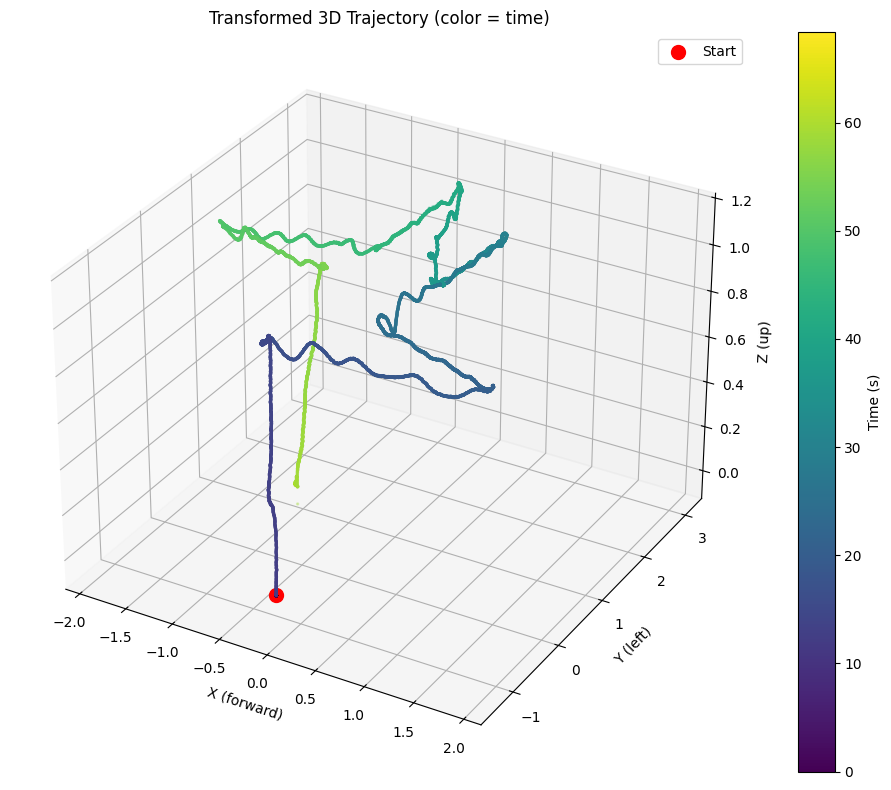

In [38]:
# 3D trajectory in the new frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(mocap_df['X'], mocap_df['Y'], mocap_df['Z'],
                c=mocap_df['Time (Seconds)'], cmap='viridis', s=2)
ax.set_xlabel('X (forward)')
ax.set_ylabel('Y (left)')
ax.set_zlabel('Z (up)')
ax.set_title('Transformed 3D Trajectory (color = time)')
# mark start point
ax.scatter(mocap_df['X'].iloc[0], mocap_df['Y'].iloc[0], mocap_df['Z'].iloc[0],
           color='red', s=100, marker='o', label='Start')
plt.colorbar(sc, label='Time (s)')
ax.legend()
plt.tight_layout()
plt.show()

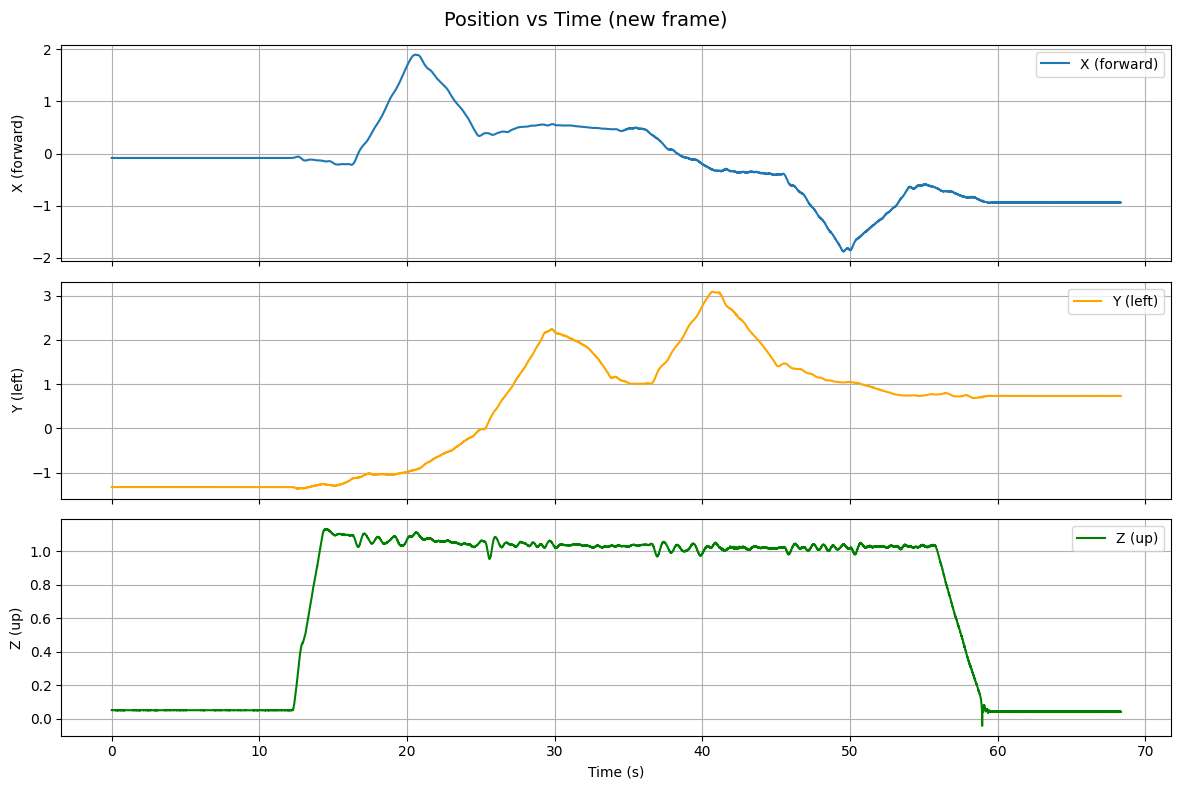

In [39]:
# X, Y, Z position vs time — should see forward/back on X first, then left/right on Y
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(mocap_df['Time (Seconds)'], mocap_df['X'], label='X (forward)')
axes[0].set_ylabel('X (forward)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mocap_df['Time (Seconds)'], mocap_df['Y'], label='Y (left)', color='orange')
axes[1].set_ylabel('Y (left)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mocap_df['Time (Seconds)'], mocap_df['Z'], label='Z (up)', color='green')
axes[2].set_ylabel('Z (up)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Position vs Time (new frame)', fontsize=14)
plt.tight_layout()
plt.show()

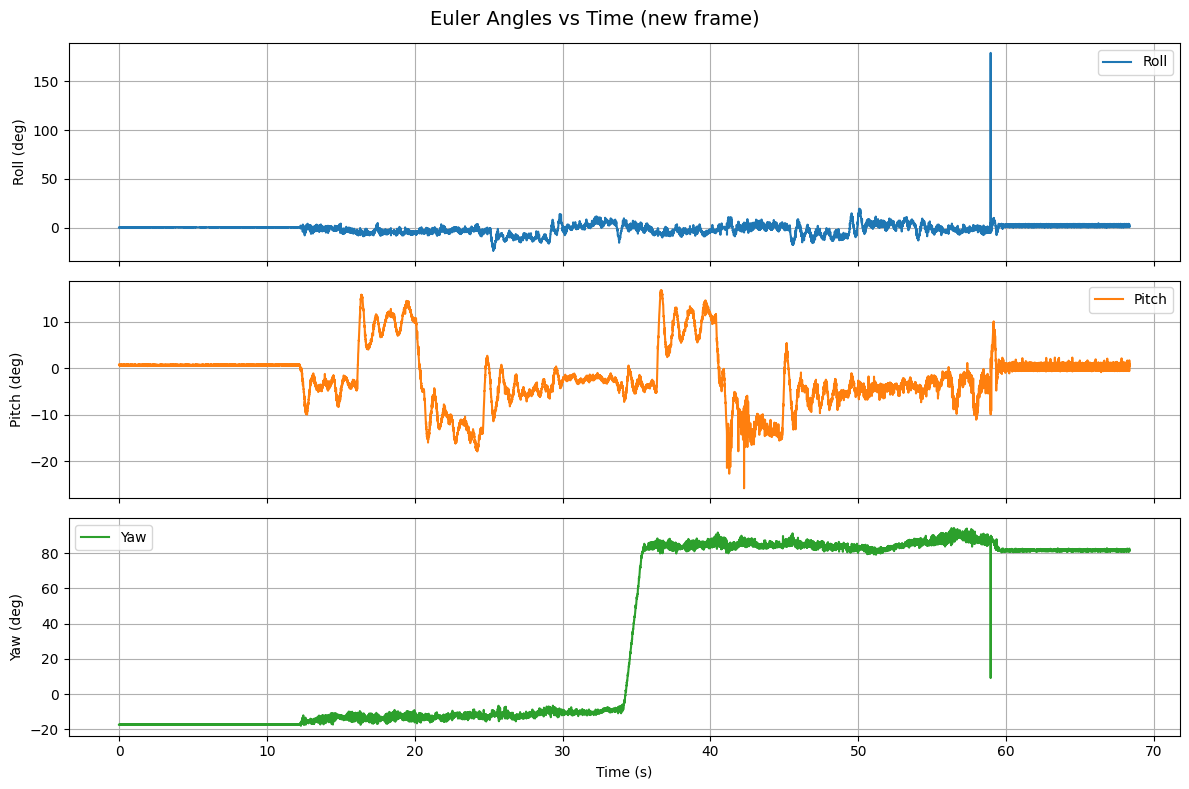

In [40]:
# Euler angles vs time — yaw should start near 0 then jump ~90 at the turn
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(mocap_df['Time (Seconds)'], mocap_df['roll'], label='Roll', color='tab:blue')
axes[0].set_ylabel('Roll (deg)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mocap_df['Time (Seconds)'], mocap_df['pitch'], label='Pitch', color='tab:orange')
axes[1].set_ylabel('Pitch (deg)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mocap_df['Time (Seconds)'], mocap_df['yaw'], label='Yaw', color='tab:green')
axes[2].set_ylabel('Yaw (deg)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Euler Angles vs Time (new frame)', fontsize=14)
plt.tight_layout()
plt.show()

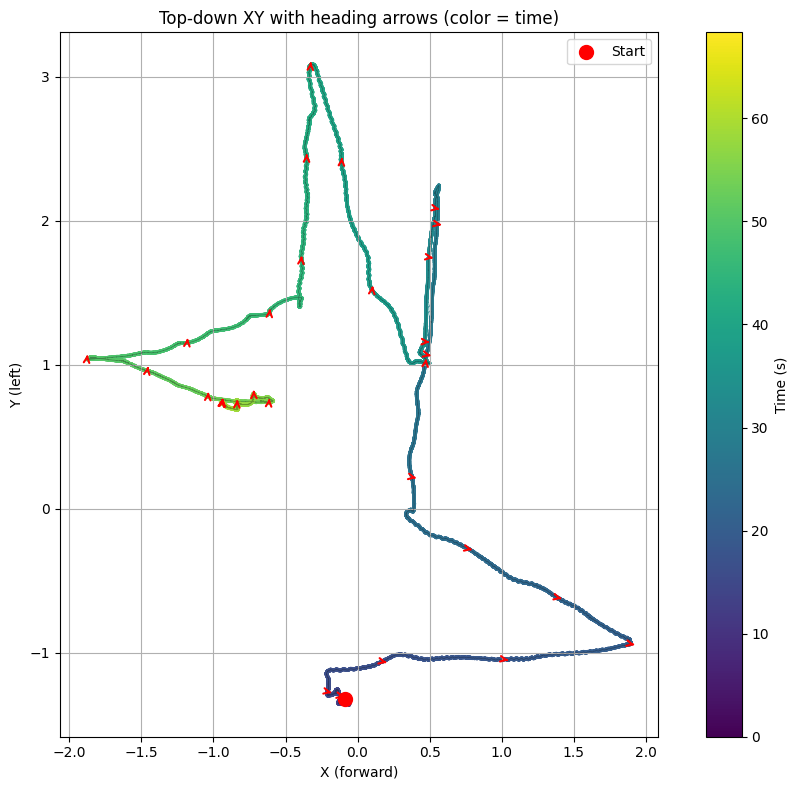

In [41]:
# Top-down view (XY plane) with heading arrows at intervals
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(mocap_df['X'], mocap_df['Y'], 'k-', alpha=0.3, linewidth=0.5)
sc = ax.scatter(mocap_df['X'], mocap_df['Y'],
                c=mocap_df['Time (Seconds)'], cmap='viridis', s=3)

# Draw heading arrows every N samples
N = max(1, len(mocap_df) // 40)
arrow_len = 0.05
for i in range(0, len(mocap_df), N):
    yaw_rad = np.radians(mocap_df['yaw'].iloc[i])
    dx = arrow_len * np.cos(yaw_rad)
    dy = arrow_len * np.sin(yaw_rad)  # positive yaw = CCW in FLU
    ax.annotate('', xy=(mocap_df['X'].iloc[i] + dx, mocap_df['Y'].iloc[i] + dy),
                xytext=(mocap_df['X'].iloc[i], mocap_df['Y'].iloc[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.scatter(mocap_df['X'].iloc[0], mocap_df['Y'].iloc[0],
           color='red', s=100, zorder=5, label='Start')
ax.set_xlabel('X (forward)')
ax.set_ylabel('Y (left)')
ax.set_title('Top-down XY with heading arrows (color = time)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)
plt.colorbar(sc, label='Time (s)')
plt.tight_layout()
plt.show()

In [42]:
import pynumdiff

# --- Smooth differentiation of world-frame position to get world-frame velocity ---
t = mocap_df['Time (Seconds)'].values
dt_mean = np.mean(np.diff(t))  # butterdiff needs uniform dt

# butterdiff for each axis
x_hat, vx_world = pynumdiff.smooth_finite_difference.butterdiff(
    mocap_df['X'].values, dt_mean, [3, 0.05])
y_hat, vy_world = pynumdiff.smooth_finite_difference.butterdiff(
    mocap_df['Y'].values, dt_mean, [3, 0.05])
z_hat, vz_world = pynumdiff.smooth_finite_difference.butterdiff(
    mocap_df['Z'].values, dt_mean, [3, 0.05])
# Stack into (N, 3) world-frame velocity
vel_world = np.column_stack([vx_world, vy_world, vz_world])

# --- Rotate world velocity into body frame ---
# rot_new maps body→world, so R^T (= R.inv()) maps world→body
vel_body = rot_new.inv().apply(vel_world)

mocap_df['vx_world'] = vx_world
mocap_df['vy_world'] = vy_world
mocap_df['vz_world'] = vz_world
mocap_df['vx_body'] = vel_body[:, 0]  # forward
mocap_df['vy_body'] = vel_body[:, 1]  # left
mocap_df['vz_body'] = vel_body[:, 2]  # up

print("Body-frame velocity columns added.")
print(mocap_df[['vx_body', 'vy_body', 'vz_body']].describe())

Body-frame velocity columns added.
            vx_body       vy_body       vz_body
count  24603.000000  24603.000000  24603.000000
mean      -0.005849      0.053863      0.035723
std        0.235502      0.211075      0.144043
min       -0.762136     -0.743394     -1.131577
25%       -0.070032     -0.008863     -0.004147
50%       -0.000316      0.005704      0.003628
75%        0.016132      0.145616      0.077927
max        0.849833      0.919598      0.890190


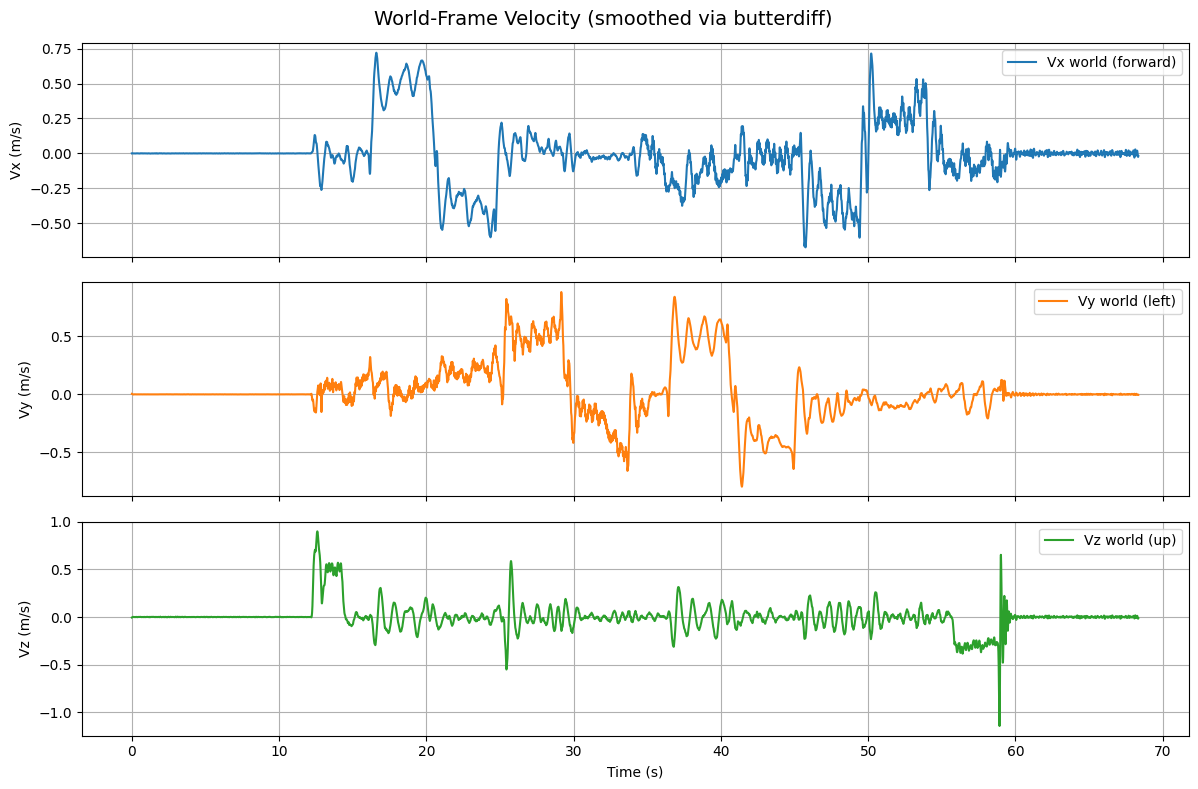

In [43]:
# --- Plot world-frame velocity ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, vx_world, label='Vx world (forward)', color='tab:blue')
axes[0].set_ylabel('Vx (m/s)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, vy_world, label='Vy world (left)', color='tab:orange')
axes[1].set_ylabel('Vy (m/s)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, vz_world, label='Vz world (up)', color='tab:green')
axes[2].set_ylabel('Vz (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('World-Frame Velocity (smoothed via butterdiff)', fontsize=14)
plt.tight_layout()
plt.show()

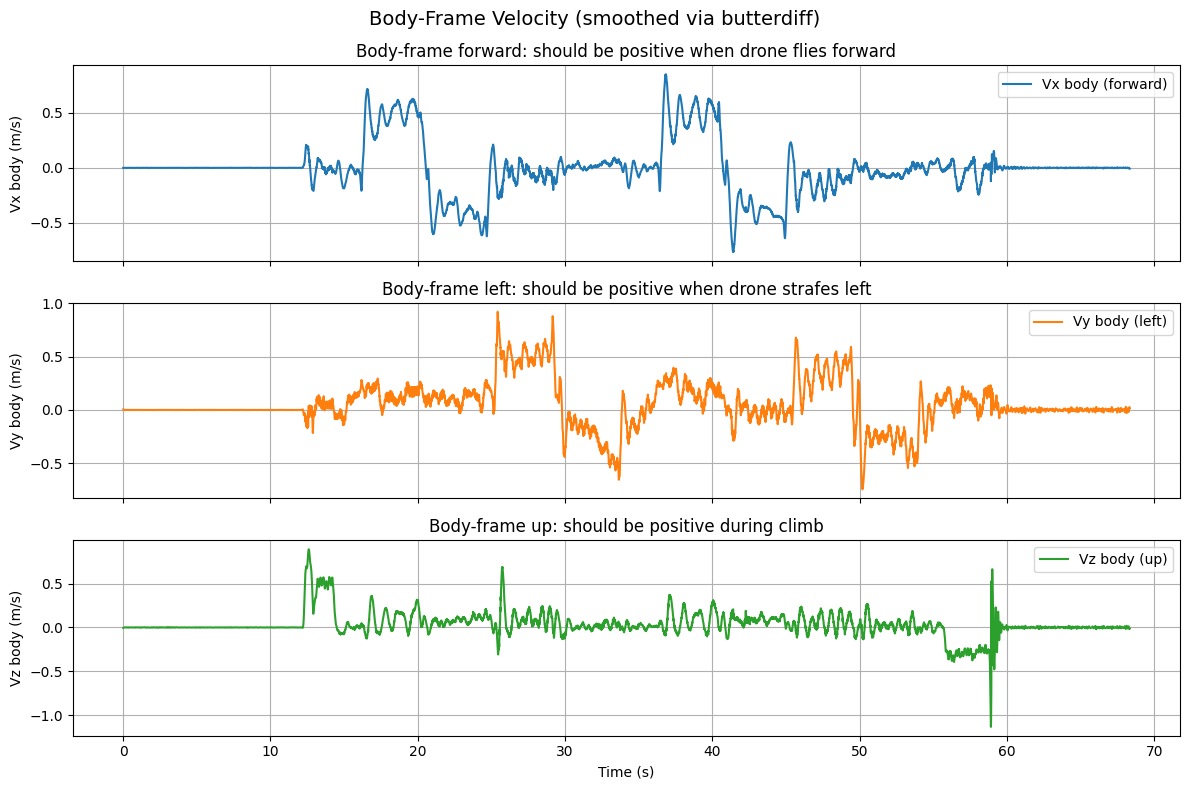

In [44]:
# --- Plot body-frame velocity ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, mocap_df['vx_body'], label='Vx body (forward)', color='tab:blue')
axes[0].set_ylabel('Vx body (m/s)')
axes[0].set_title('Body-frame forward: should be positive when drone flies forward')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, mocap_df['vy_body'], label='Vy body (left)', color='tab:orange')
axes[1].set_ylabel('Vy body (m/s)')
axes[1].set_title('Body-frame left: should be positive when drone strafes left')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, mocap_df['vz_body'], label='Vz body (up)', color='tab:green')
axes[2].set_ylabel('Vz body (m/s)')
axes[2].set_title('Body-frame up: should be positive during climb')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Body-Frame Velocity (smoothed via butterdiff)', fontsize=14)
plt.tight_layout()
plt.show()

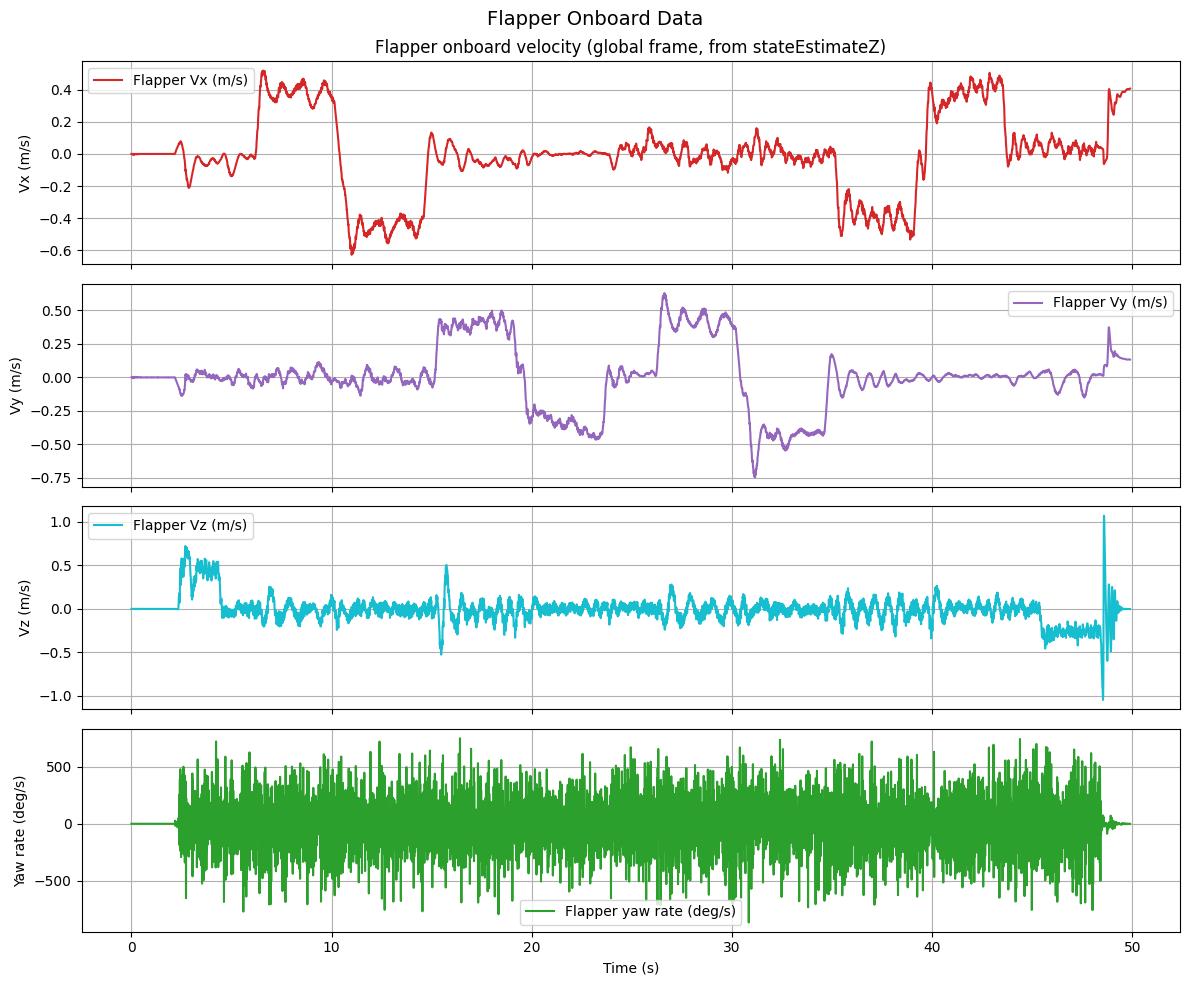

NOTE: stateEstimateZ vx/vy/vz are in the Crazyflie GLOBAL frame (FLU-like)
      rateYaw was millirad/s in firmware, converted to deg/s here


In [45]:
# --- Convert flapper units and plot ---
# From firmware: vx/vy/vz are in mm/s (global frame), rateYaw is in millirad/s

flapper_df['vx_m_s'] = flapper_df['stateEstimateZ.vx'] / 1000.0   # mm/s → m/s
flapper_df['vy_m_s'] = flapper_df['stateEstimateZ.vy'] / 1000.0
flapper_df['vz_m_s'] = flapper_df['stateEstimateZ.vz'] / 1000.0
flapper_df['rateYaw_deg_s'] = flapper_df['stateEstimateZ.rateYaw'] / 1000.0 * (180.0 / np.pi)  # mrad/s → deg/s

t_flap = flapper_df['t_s'].values

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_flap, flapper_df['vx_m_s'], label='Flapper Vx (m/s)', color='tab:red')
axes[0].set_ylabel('Vx (m/s)')
axes[0].set_title('Flapper onboard velocity (global frame, from stateEstimateZ)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_flap, flapper_df['vy_m_s'], label='Flapper Vy (m/s)', color='tab:purple')
axes[1].set_ylabel('Vy (m/s)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_flap, flapper_df['vz_m_s'], label='Flapper Vz (m/s)', color='tab:cyan')
axes[2].set_ylabel('Vz (m/s)')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(t_flap, flapper_df['rateYaw_deg_s'], label='Flapper yaw rate (deg/s)', color='tab:green')
axes[3].set_ylabel('Yaw rate (deg/s)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()
axes[3].grid(True)

fig.suptitle('Flapper Onboard Data', fontsize=14)
plt.tight_layout()
plt.show()

print(f"NOTE: stateEstimateZ vx/vy/vz are in the Crazyflie GLOBAL frame (FLU-like)")
print(f"      rateYaw was millirad/s in firmware, converted to deg/s here")

Best time offset (mocap_t − flapper_t): 10.200 s
Flapper boot yaw (mocap frame): -17.36°
→ Flapper's internal global X is rotated -17.36° from mocap X


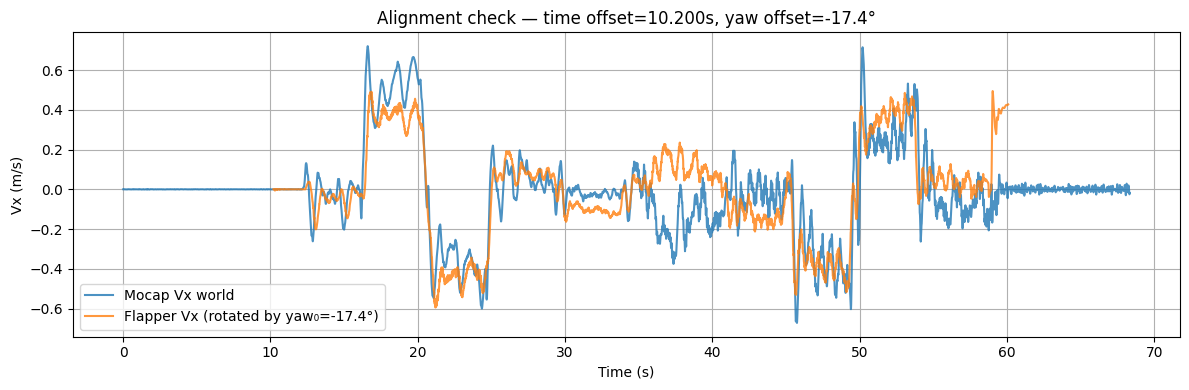

In [46]:
# --- Time synchronization ---
# The flapper's "global" frame is initialized at boot with X = drone's nose direction.
# That means flapper vx/vy are in a frame rotated by yaw_0 (the mocap yaw at boot) 
# relative to the mocap world frame. We need to account for this.
#
# Strategy:
#   1. Cross-correlate using the MAGNITUDE of horizontal velocity (frame-independent!)
#   2. Find the time offset
#   3. Determine yaw_0 from mocap at flapper start time
#   4. Rotate flapper velocity into mocap world frame using yaw_0

from scipy.interpolate import interp1d
from scipy.signal import correlate

# Compute horizontal speed magnitude (frame-independent) for cross-correlation
mocap_hspeed = np.sqrt(mocap_df['vx_world'].values**2 + mocap_df['vy_world'].values**2)
flapper_hspeed = np.sqrt(flapper_df['vx_m_s'].values**2 + flapper_df['vy_m_s'].values**2)

# Resample both to a common uniform grid
dt_common = 0.01  # 100 Hz
t_start = max(mocap_df['Time (Seconds)'].min(), flapper_df['t_s'].min())
t_end   = min(mocap_df['Time (Seconds)'].max(), flapper_df['t_s'].max())
t_common = np.arange(t_start, t_end, dt_common)

f_mocap_hs = interp1d(mocap_df['Time (Seconds)'], mocap_hspeed,
                       bounds_error=False, fill_value=0)
f_flap_hs = interp1d(flapper_df['t_s'], flapper_hspeed,
                      bounds_error=False, fill_value=0)
mocap_hs_resampled = f_mocap_hs(t_common)
flap_hs_resampled  = f_flap_hs(t_common)

# Cross-correlate to find time offset
corr = correlate(mocap_hs_resampled - np.mean(mocap_hs_resampled),
                 flap_hs_resampled  - np.mean(flap_hs_resampled), mode='full')
lags = np.arange(-len(t_common) + 1, len(t_common)) * dt_common
best_lag = lags[np.argmax(corr)]

print(f"Best time offset (mocap_t − flapper_t): {best_lag:.3f} s")

# Apply offset to flapper time
flapper_df['t_aligned'] = flapper_df['t_s'] + best_lag

# --- Determine yaw_0: the mocap yaw when the flapper was first powered on ---
# The flapper's t_s=0 corresponds to mocap t = best_lag
# Use the average yaw during the first ~2s of flapper data (sitting still on ground)
flap_start_mocap_t = best_lag
flap_init_window = 2.0  # seconds
mask_init = ((mocap_df['Time (Seconds)'] >= flap_start_mocap_t) & 
             (mocap_df['Time (Seconds)'] <= flap_start_mocap_t + flap_init_window))

if mask_init.sum() > 0:
    yaw_0 = np.mean(mocap_df.loc[mask_init, 'yaw'])
else:
    # fallback: use first few mocap samples
    yaw_0 = mocap_df['yaw'].iloc[:100].mean()

print(f"Flapper boot yaw (mocap frame): {yaw_0:.2f}°")
print(f"→ Flapper's internal global X is rotated {yaw_0:.2f}° from mocap X")

# --- Rotate flapper velocity from its internal global frame to mocap global frame ---
yaw_0_rad = np.radians(yaw_0)
c, s = np.cos(yaw_0_rad), np.sin(yaw_0_rad)
# 2D rotation: [vx_mocap, vy_mocap] = Rz(yaw_0) @ [vx_flap, vy_flap]
flapper_df['vx_mocap'] = c * flapper_df['vx_m_s'] - s * flapper_df['vy_m_s']
flapper_df['vy_mocap'] = s * flapper_df['vx_m_s'] + c * flapper_df['vy_m_s']
flapper_df['vz_mocap'] = flapper_df['vz_m_s']  # Z (up) is shared

# Quick visual check
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mocap_df['Time (Seconds)'], mocap_df['vx_world'], label='Mocap Vx world', alpha=0.8)
ax.plot(flapper_df['t_aligned'], flapper_df['vx_mocap'],
        label=f'Flapper Vx (rotated by yaw₀={yaw_0:.1f}°)', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vx (m/s)')
ax.set_title(f'Alignment check — time offset={best_lag:.3f}s, yaw offset={yaw_0:.1f}°')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

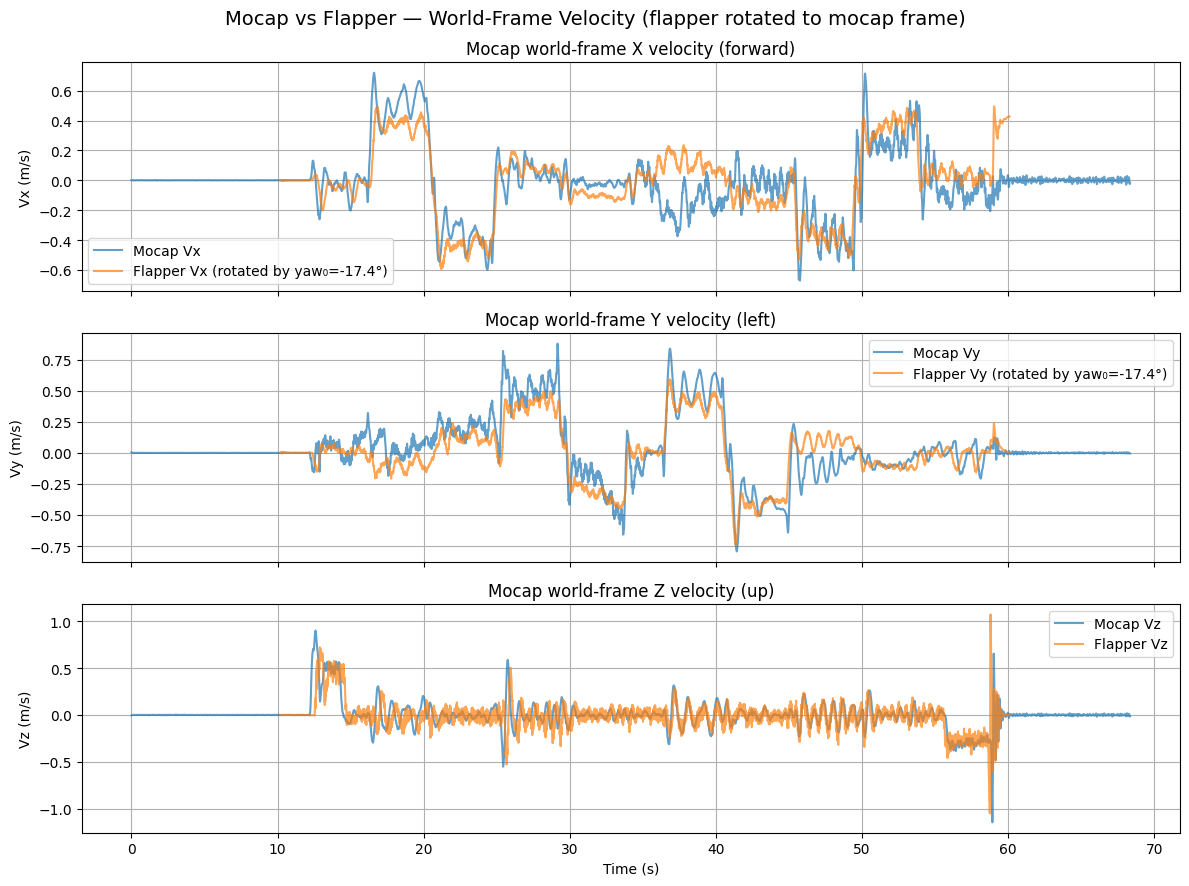

In [47]:
# --- Compare mocap vs flapper: world-frame velocity (properly rotated) ---
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(mocap_df['Time (Seconds)'], mocap_df['vx_world'],
             label='Mocap Vx', alpha=0.7)
axes[0].plot(flapper_df['t_aligned'], flapper_df['vx_mocap'],
             label=f'Flapper Vx (rotated by yaw₀={yaw_0:.1f}°)', alpha=0.7)
axes[0].set_ylabel('Vx (m/s)')
axes[0].set_title('Mocap world-frame X velocity (forward)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mocap_df['Time (Seconds)'], mocap_df['vy_world'],
             label='Mocap Vy', alpha=0.7)
axes[1].plot(flapper_df['t_aligned'], flapper_df['vy_mocap'],
             label=f'Flapper Vy (rotated by yaw₀={yaw_0:.1f}°)', alpha=0.7)
axes[1].set_ylabel('Vy (m/s)')
axes[1].set_title('Mocap world-frame Y velocity (left)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mocap_df['Time (Seconds)'], mocap_df['vz_world'],
             label='Mocap Vz', alpha=0.7)
axes[2].plot(flapper_df['t_aligned'], flapper_df['vz_mocap'],
             label='Flapper Vz', alpha=0.7)
axes[2].set_ylabel('Vz (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Mocap world-frame Z velocity (up)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Mocap vs Flapper — World-Frame Velocity (flapper rotated to mocap frame)', fontsize=14)
plt.tight_layout()
plt.show()

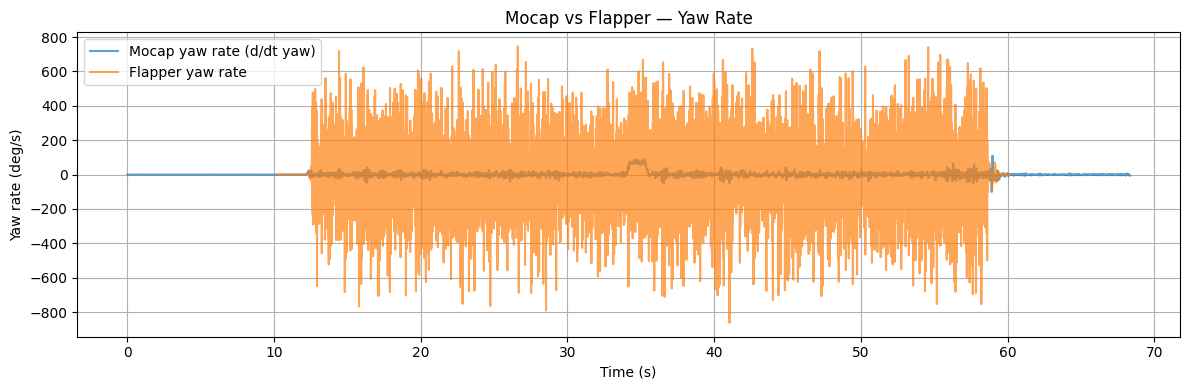

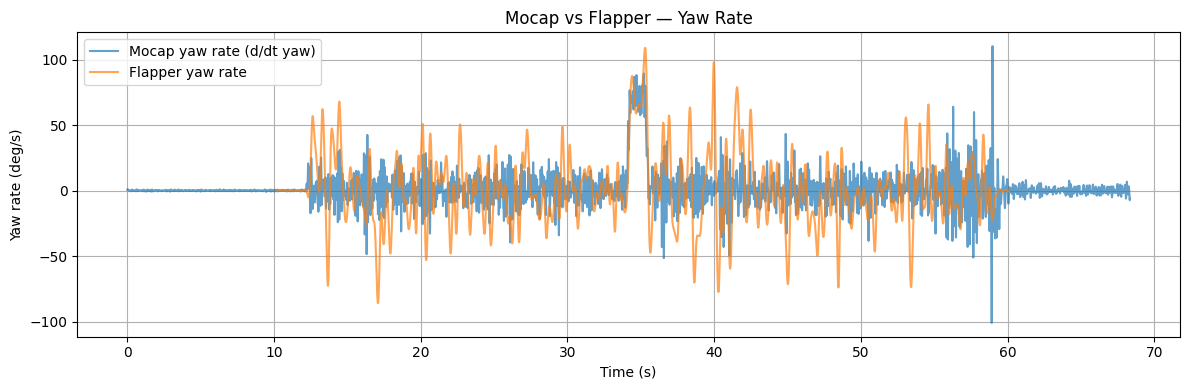

In [48]:
# --- Compare yaw rate: mocap (differentiated yaw) vs flapper rateYaw ---
# Compute mocap yaw rate via butterdiff
_, yawrate_mocap = pynumdiff.smooth_finite_difference.butterdiff(
    mocap_df['yaw'].values, dt_mean, [3, 0.05])
yawrate_flapper, _ = pynumdiff.smooth_finite_difference.butterdiff(
    flapper_df['rateYaw_deg_s'].values, dt_mean, [3, 0.05])  # flapper rateYaw is already in deg/s

mocap_df['yawrate_deg_s'] = yawrate_mocap

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mocap_df['Time (Seconds)'], mocap_df['yawrate_deg_s'],
        label='Mocap yaw rate (d/dt yaw)', alpha=0.7)
ax.plot(flapper_df['t_aligned'], flapper_df['rateYaw_deg_s'],
        label='Flapper yaw rate', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw rate (deg/s)')
ax.set_title('Mocap vs Flapper — Yaw Rate')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mocap_df['Time (Seconds)'], mocap_df['yawrate_deg_s'],
        label='Mocap yaw rate (d/dt yaw)', alpha=0.7)
ax.plot(flapper_df['t_aligned'], yawrate_flapper,
        label='Flapper yaw rate', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw rate (deg/s)')
ax.set_title('Mocap vs Flapper — Yaw Rate')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

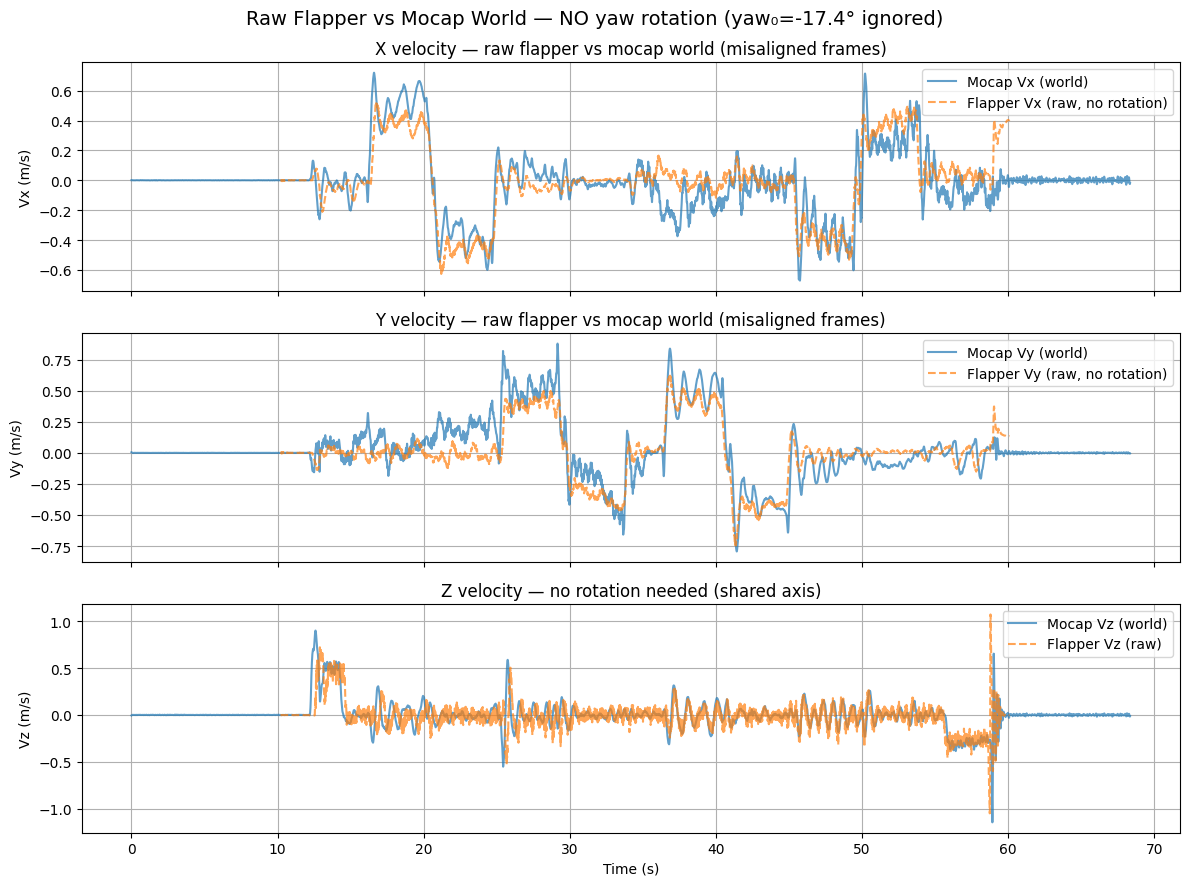

In [49]:
# --- Plot 1: Raw flapper velocity (NO rotation) vs mocap world-frame velocity ---
# This shows the effect of the unknown yaw offset
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(mocap_df['Time (Seconds)'], mocap_df['vx_world'],
             label='Mocap Vx (world)', alpha=0.7)
axes[0].plot(flapper_df['t_aligned'], flapper_df['vx_m_s'],
             label='Flapper Vx (raw, no rotation)', alpha=0.7, linestyle='--')
axes[0].set_ylabel('Vx (m/s)')
axes[0].set_title('X velocity — raw flapper vs mocap world (misaligned frames)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mocap_df['Time (Seconds)'], mocap_df['vy_world'],
             label='Mocap Vy (world)', alpha=0.7)
axes[1].plot(flapper_df['t_aligned'], flapper_df['vy_m_s'],
             label='Flapper Vy (raw, no rotation)', alpha=0.7, linestyle='--')
axes[1].set_ylabel('Vy (m/s)')
axes[1].set_title('Y velocity — raw flapper vs mocap world (misaligned frames)')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mocap_df['Time (Seconds)'], mocap_df['vz_world'],
             label='Mocap Vz (world)', alpha=0.7)
axes[2].plot(flapper_df['t_aligned'], flapper_df['vz_m_s'],
             label='Flapper Vz (raw)', alpha=0.7, linestyle='--')
axes[2].set_ylabel('Vz (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Z velocity — no rotation needed (shared axis)')
axes[2].legend()
axes[2].grid(True)

fig.suptitle(f'Raw Flapper vs Mocap World — NO yaw rotation (yaw₀={yaw_0:.1f}° ignored)', fontsize=14)
plt.tight_layout()
plt.show()

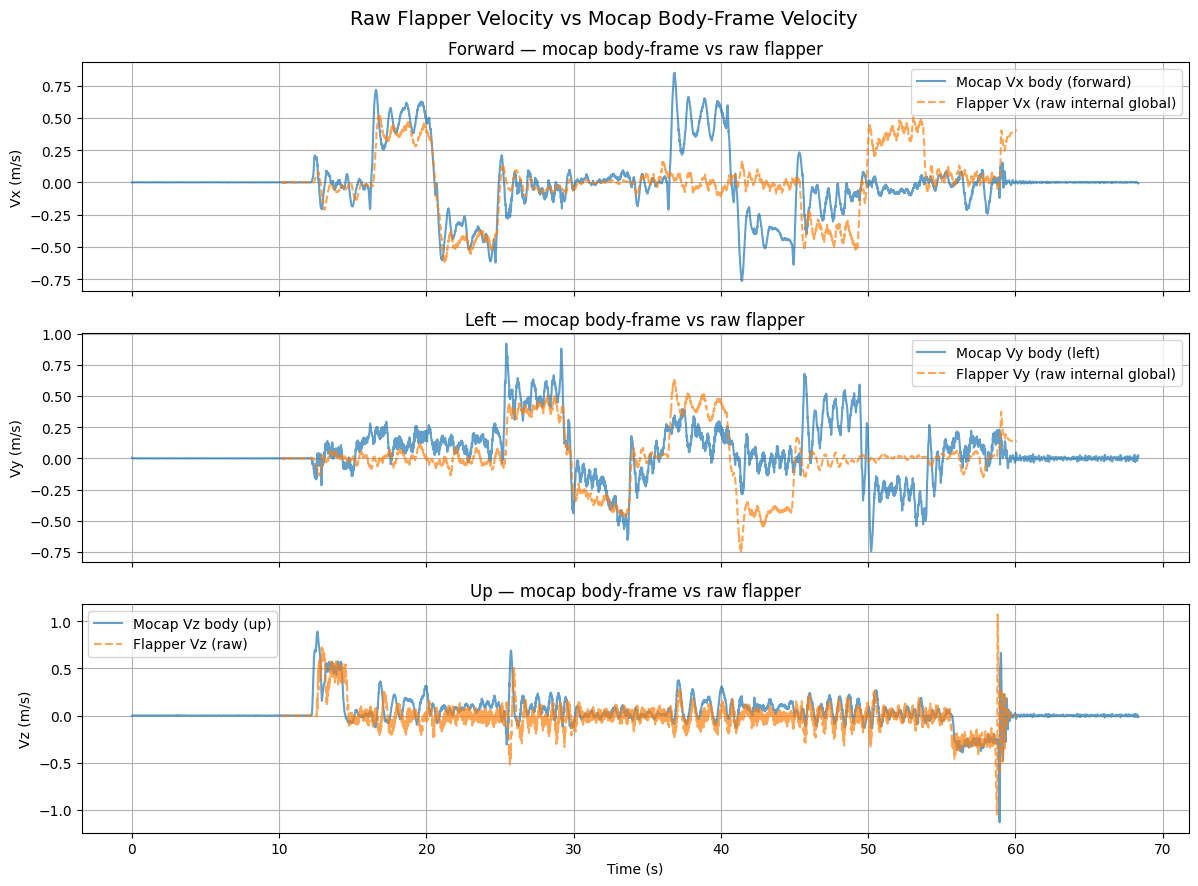

In [50]:
# --- Plot 2: Raw flapper velocity vs mocap BODY-frame velocity ---
# The flapper's "global" frame drifts with yaw over time, so it won't match body frame
# exactly. But this is a useful comparison since both are "drone-centric".
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(mocap_df['Time (Seconds)'], mocap_df['vx_body'],
             label='Mocap Vx body (forward)', alpha=0.7)
axes[0].plot(flapper_df['t_aligned'], flapper_df['vx_m_s'],
             label='Flapper Vx (raw internal global)', alpha=0.7, linestyle='--')
axes[0].set_ylabel('Vx (m/s)')
axes[0].set_title('Forward — mocap body-frame vs raw flapper')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mocap_df['Time (Seconds)'], mocap_df['vy_body'],
             label='Mocap Vy body (left)', alpha=0.7)
axes[1].plot(flapper_df['t_aligned'], flapper_df['vy_m_s'],
             label='Flapper Vy (raw internal global)', alpha=0.7, linestyle='--')
axes[1].set_ylabel('Vy (m/s)')
axes[1].set_title('Left — mocap body-frame vs raw flapper')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(mocap_df['Time (Seconds)'], mocap_df['vz_body'],
             label='Mocap Vz body (up)', alpha=0.7)
axes[2].plot(flapper_df['t_aligned'], flapper_df['vz_m_s'],
             label='Flapper Vz (raw)', alpha=0.7, linestyle='--')
axes[2].set_ylabel('Vz (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Up — mocap body-frame vs raw flapper')
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Raw Flapper Velocity vs Mocap Body-Frame Velocity', fontsize=14)
plt.tight_layout()
plt.show()

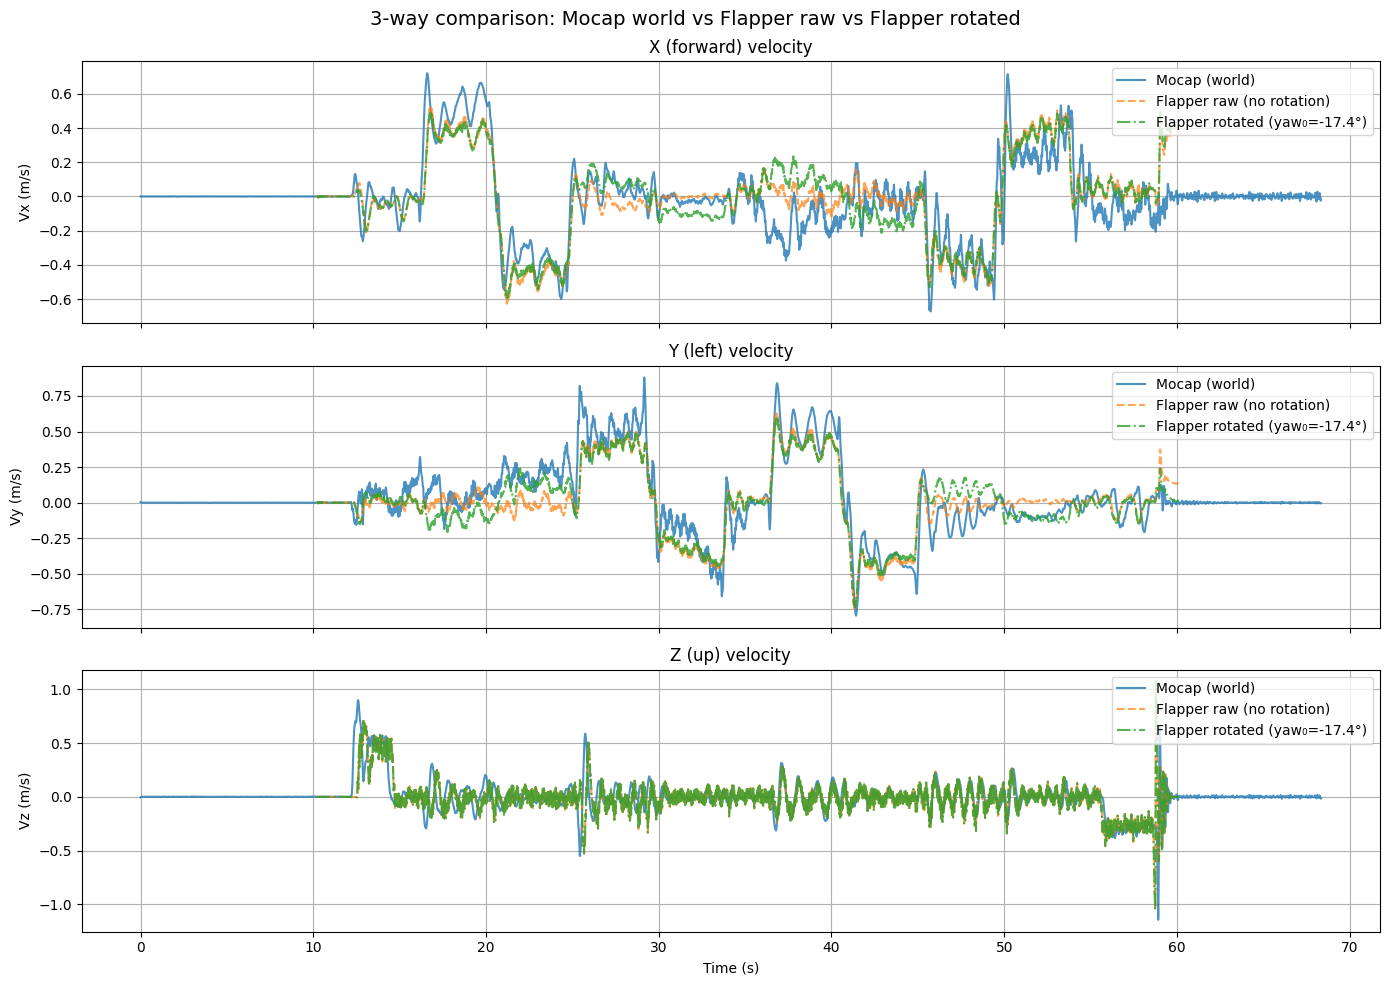

In [51]:
# --- 3-way comparison: Mocap world, Flapper raw (no rotation), Flapper rotated ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax_i, axis_label, mocap_col, flap_raw, flap_rot in [
    (axes[0], 'X (forward)', 'vx_world', 'vx_m_s', 'vx_mocap'),
    (axes[1], 'Y (left)',    'vy_world', 'vy_m_s', 'vy_mocap'),
    (axes[2], 'Z (up)',      'vz_world', 'vz_m_s', 'vz_mocap'),
]:
    ax_i.plot(mocap_df['Time (Seconds)'], mocap_df[mocap_col],
              label='Mocap (world)', color='tab:blue', alpha=0.8)
    ax_i.plot(flapper_df['t_aligned'], flapper_df[flap_raw],
              label='Flapper raw (no rotation)', color='tab:orange', alpha=0.7, linestyle='--')
    ax_i.plot(flapper_df['t_aligned'], flapper_df[flap_rot],
              label=f'Flapper rotated (yaw₀={yaw_0:.1f}°)', color='tab:green', alpha=0.8, linestyle='-.')
    ax_i.set_ylabel(f'V{axis_label[0].lower()} (m/s)')
    ax_i.set_title(f'{axis_label} velocity')
    ax_i.legend(loc='upper right')
    ax_i.grid(True)

axes[2].set_xlabel('Time (s)')
fig.suptitle('3-way comparison: Mocap world vs Flapper raw vs Flapper rotated', fontsize=14)
plt.tight_layout()
plt.show()

FlightComparison ready
  time offset (mocap − flapper) : +10.200 s
  yaw₀ (flapper boot → mocap)   : -17.4°


(<Figure size 1400x1000 with 3 Axes>,
 array([<Axes: title={'center': 'X (forward) velocity'}, ylabel='Vx (m/s)'>,
        <Axes: title={'center': 'Y (left) velocity'}, ylabel='Vy (m/s)'>,
        <Axes: title={'center': 'Z (up) velocity'}, xlabel='Time (s)', ylabel='Vz (m/s)'>],
       dtype=object))

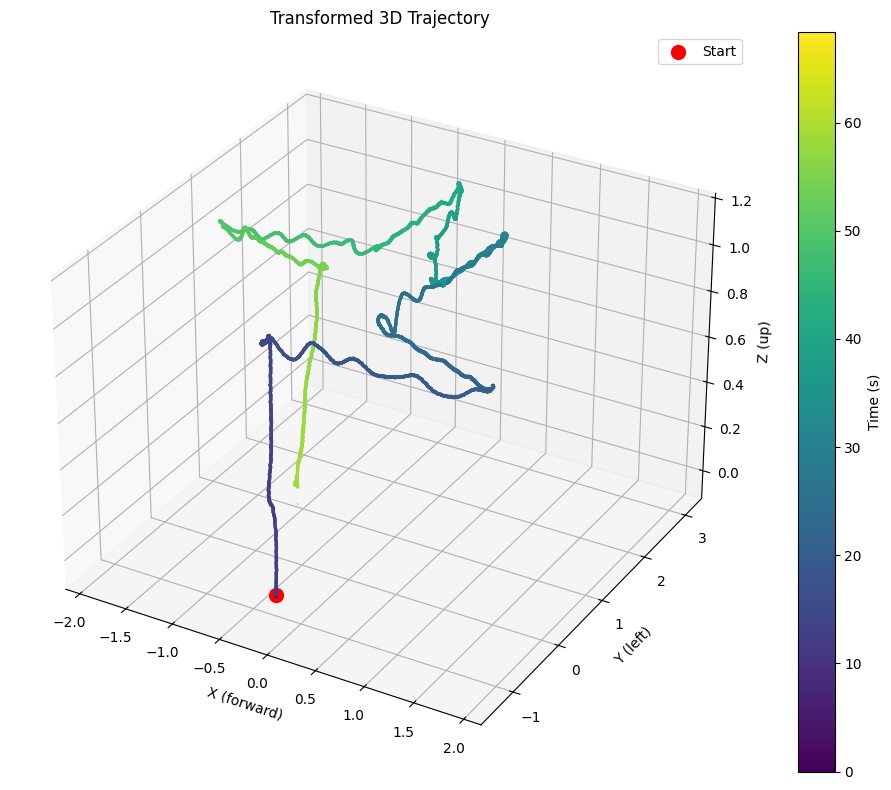

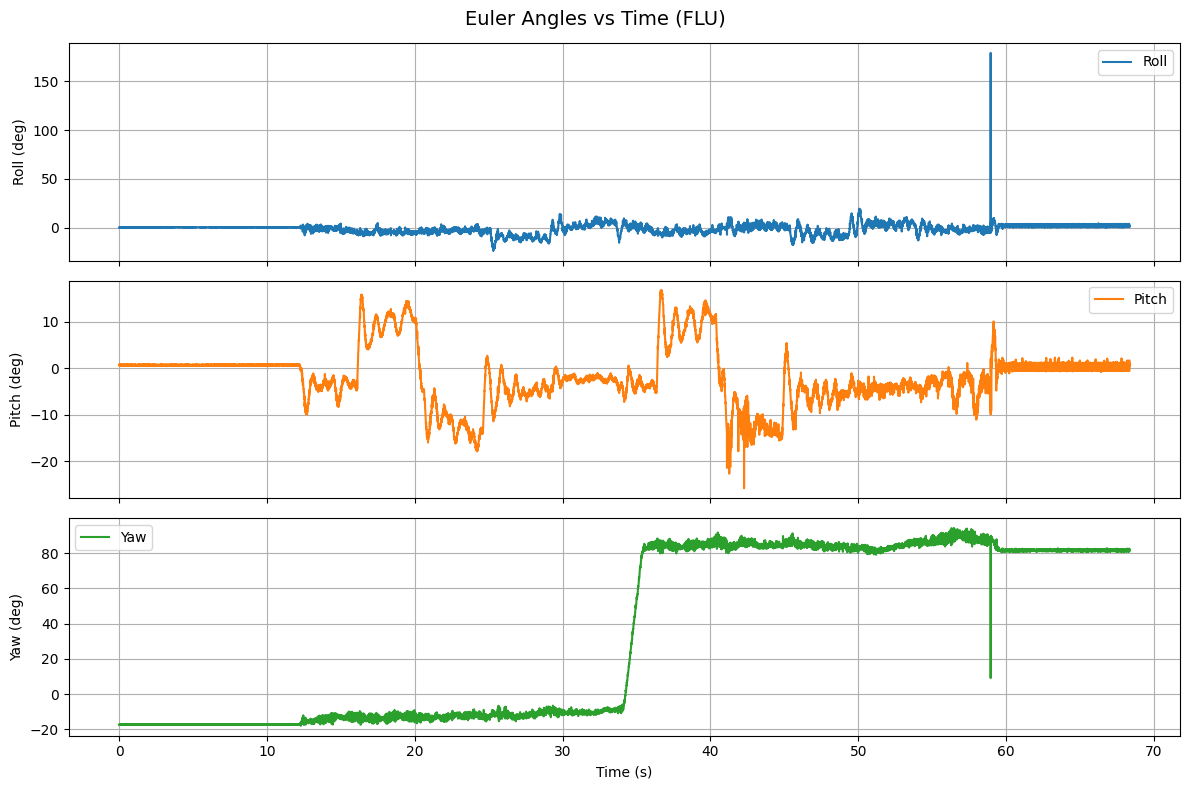

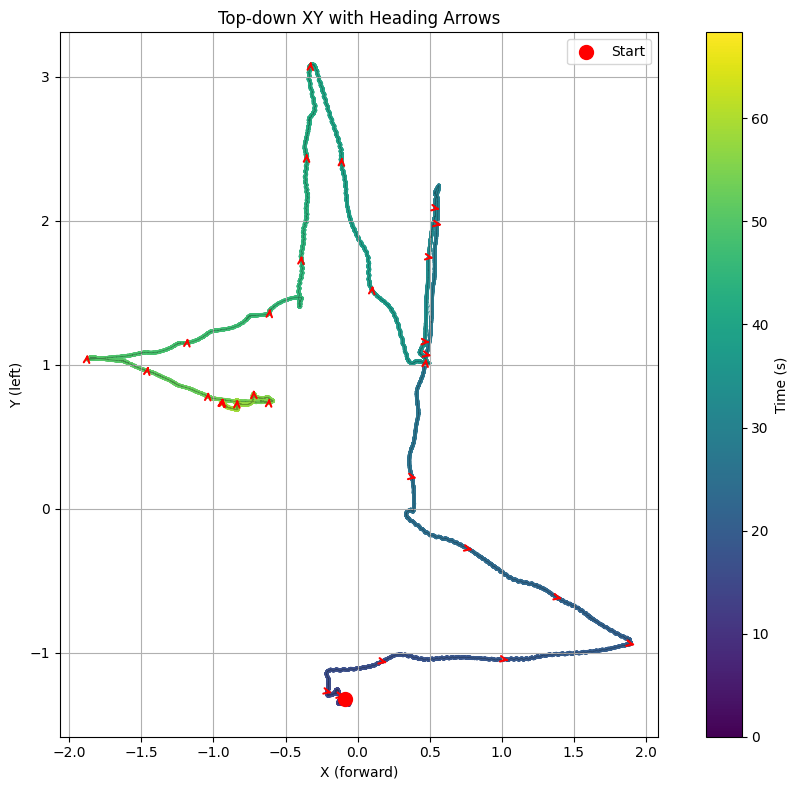

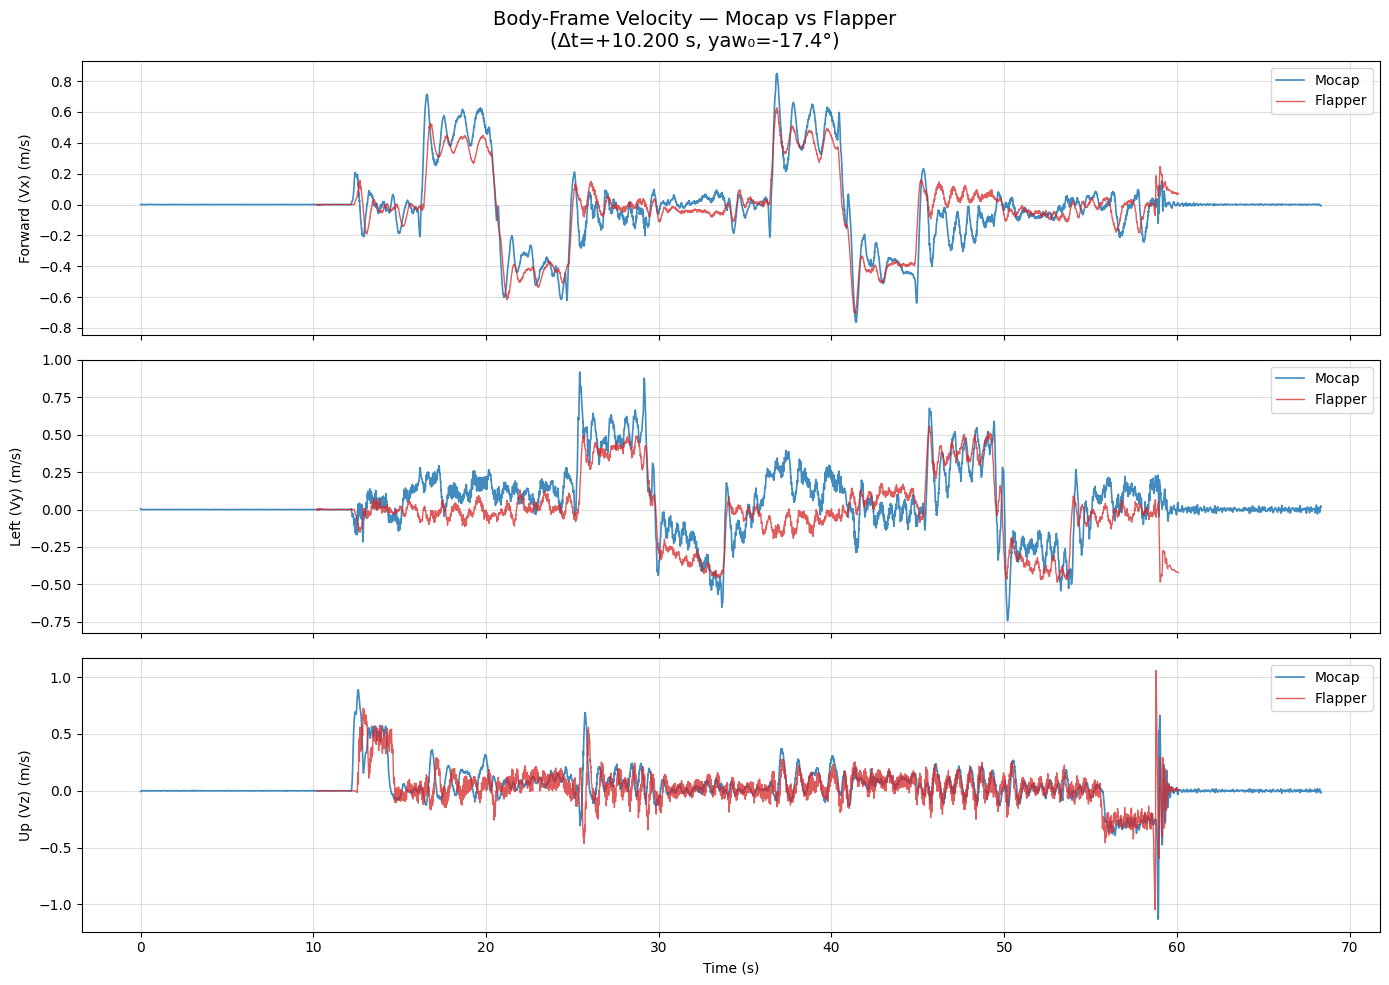

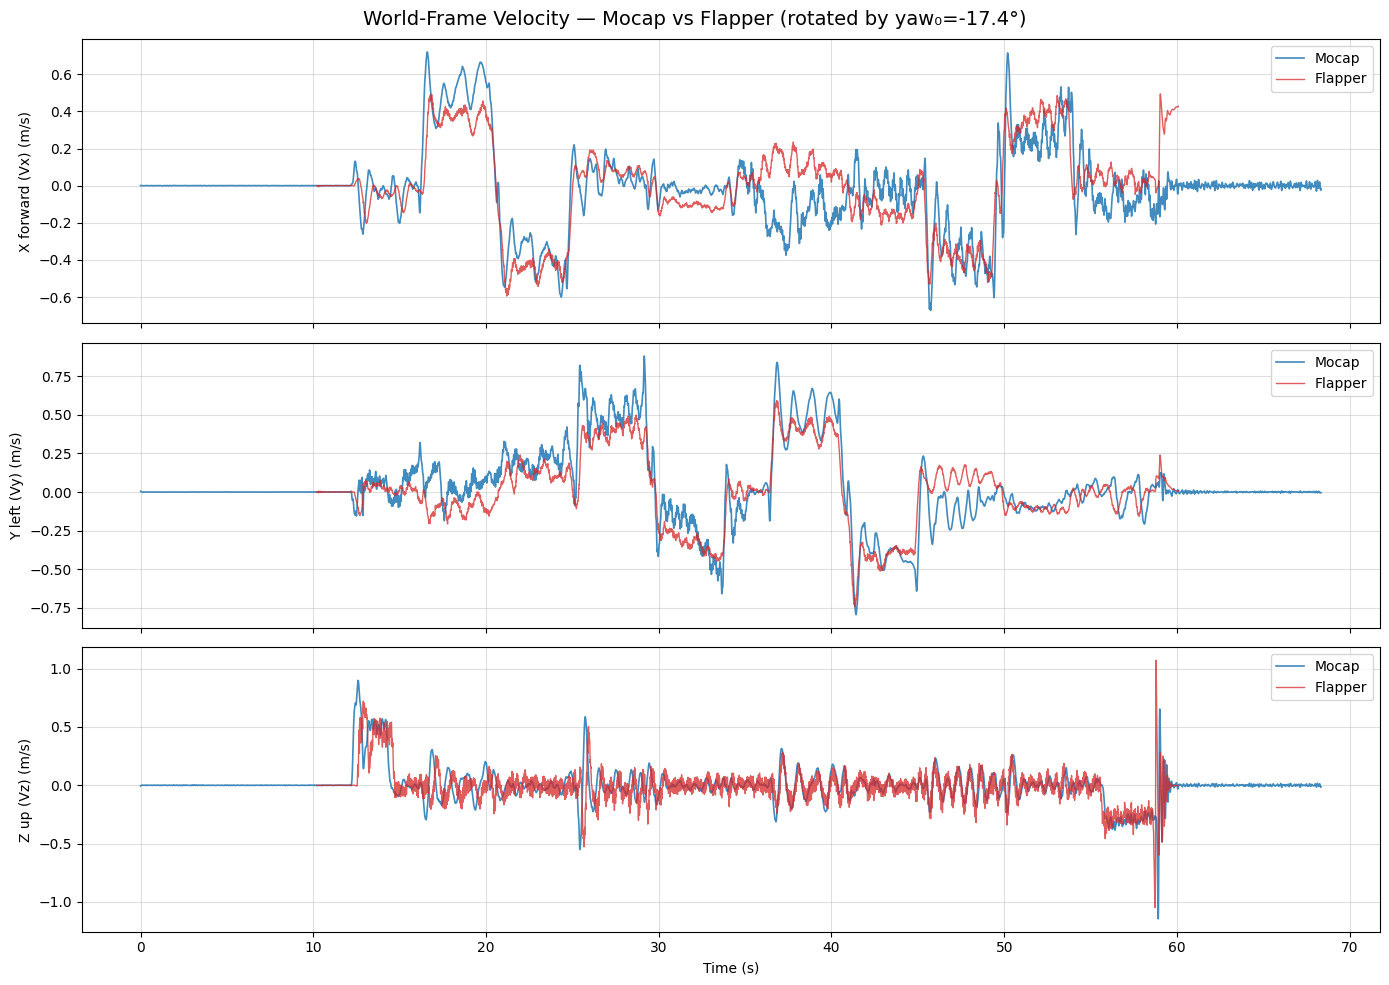

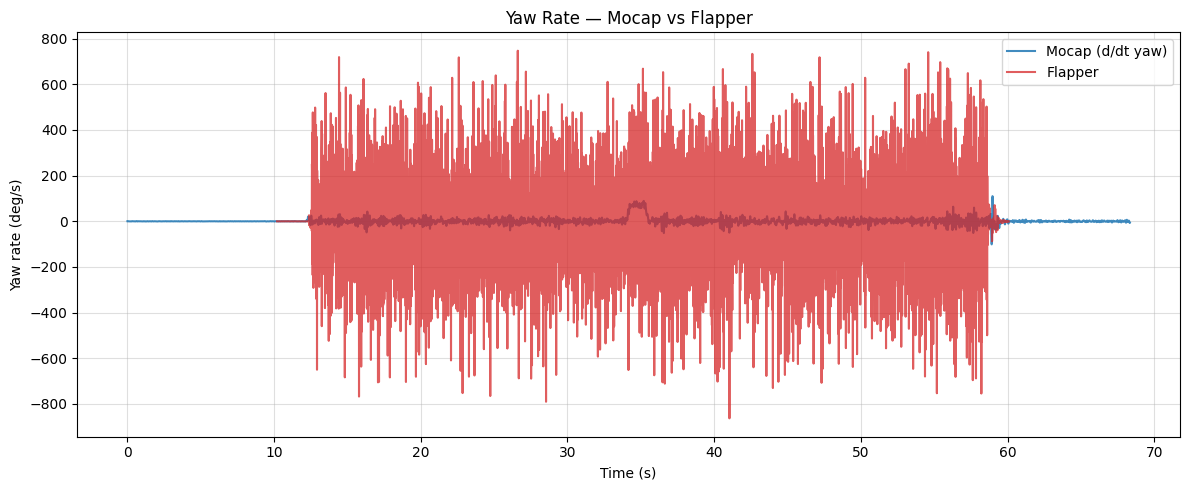

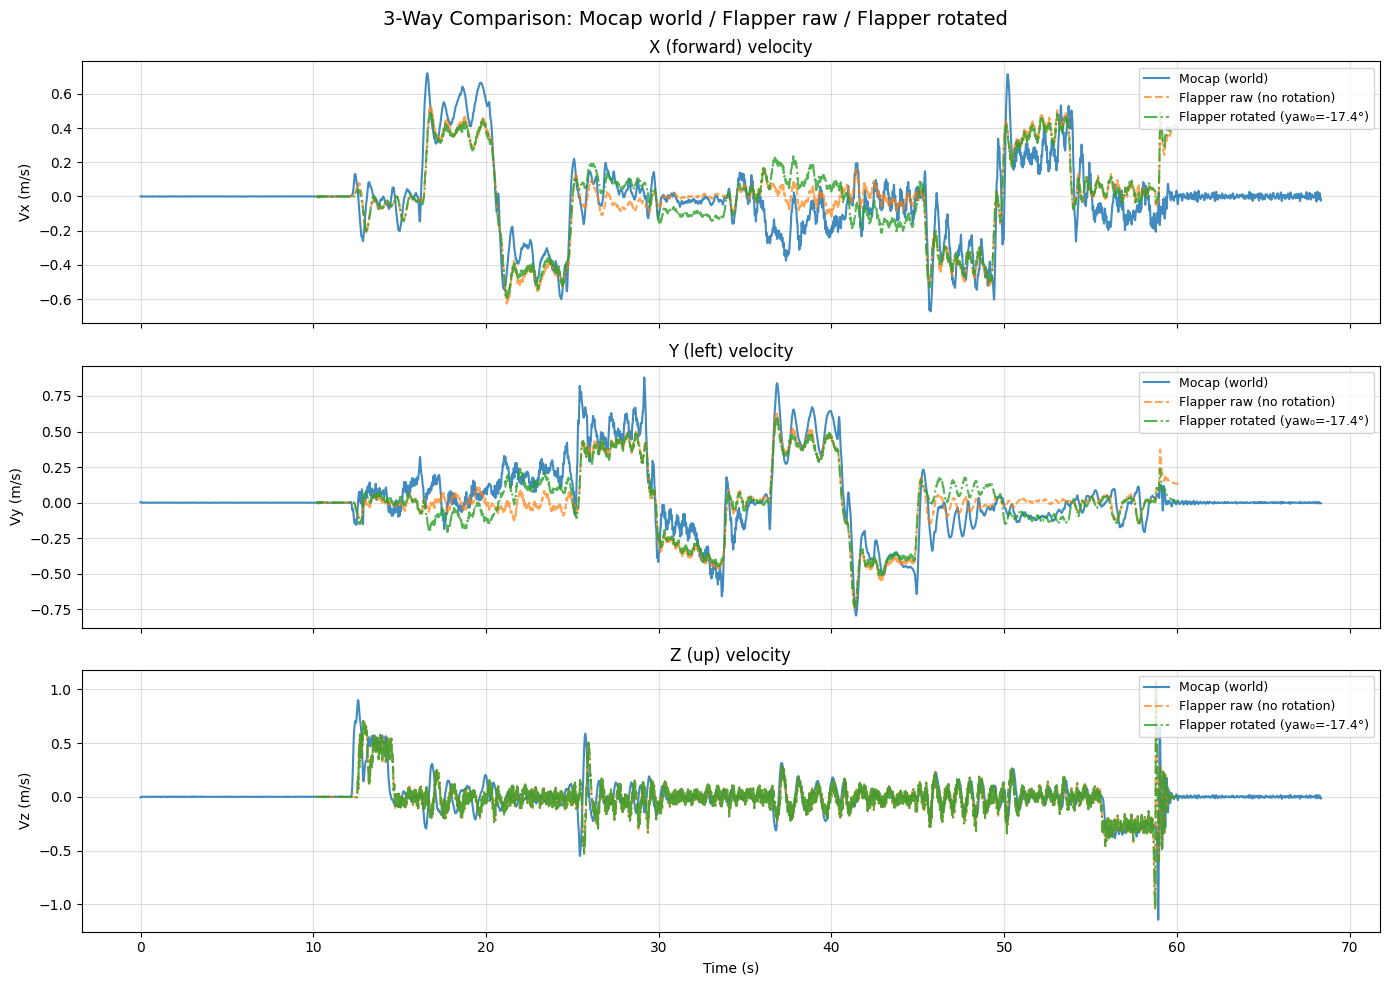

In [52]:
from mocap_utils import MocapProcessor, FlapperProcessor, FlightComparison

CAL_DIR = "/home/austin/crazyflie-firmware/examples/app_flapper_swarm/analysis/cal"

# --- Load & process mocap ---
mp = MocapProcessor(f"{CAL_DIR}/mocap1cal01.csv")
mp.compute_velocity()
mp.compute_rates()

# --- Load flapper ---
fp = FlapperProcessor(f"{CAL_DIR}/flap1cal01.csv")

# --- Compare: auto time-sync, yaw₀ estimation, body-frame transform ---
fc = FlightComparison(mp, fp)

# Individual mocap plots
mp.plot_trajectory_3d()
mp.plot_euler_vs_time()
mp.plot_topdown_heading()

# The main comparison plots
fc.plot_body_velocity_comparison()
fc.plot_world_velocity_comparison()
fc.plot_yaw_rate_comparison()
fc.plot_three_way_velocity()